In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 
import math
from cartopy.util import add_cyclic_point
from sklearn import linear_model as lm
import statsmodels.formula.api as stm
from sklearn.metrics import r2_score
from numpy import genfromtxt
import rioxarray

from datetime import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import seaborn as sns
#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import matplotlib.cm as cm
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

plt.rcParams['hatch.linewidth'] = 1.5
plt.rcParams['hatch.color'] = 'k'
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Arial"
mpl.rcParams['font.size'] = "16"
from matplotlib import rcParams
rcParams["mathtext.default"] = "regular"

import warnings
warnings.filterwarnings(action='ignore')

/dartfs-hpc/rc/home/q/f006fqq/.conda/envs/cl1020/lib/python3.8/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [2]:
cmip_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/ClimateModels/CMIP6/'
gleam_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GLEAM/v3.8a/monthly/'
tc_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/TerraClimate/'
cmip_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/ClimateModels/CMIP6/historical/'
era_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/ERA5-Land/monthly/'
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/'
gpcc_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/'
cru_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CRU_TS/pre/'
chirps_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CHIRPS-V2/p25/'

In [3]:
def flipLon(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = (dsshift.lon.values + 180) % 360 - 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

In [4]:
# load in the sftlf land masks for each model 
# and interpolate the mdl's lai mask from the ensemble mean.
mask = xr.open_dataset(save_dir+'IMERG_land_sea_mask.nc')
mask = mask.interp_like(gpcp_ds)
mask = mask.landseamask < 75

NameError: name 'gpcp_ds' is not defined

### annual water year gini on daily precip

In [8]:
# obs directories
cpc_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CPC/ppt/'
chirps_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/CHIRPS-V2/'
gleam_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GLEAM/v3.8a/daily/'
gpcp_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCP/v1.3_daily/'

In [9]:
def gini(x):
    # computes unweighted gini index on a vector
    # from: https://stackoverflow.com/questions/48999542/more-efficient-weighted-gini-coefficient-in-python
    # equivalent to (np.sum((2 * index - n  - 1) * x)) / (n * np.sum(x)), which is more common notation but slower
    
    n = len(x)
    
    # if obs missing, drop
    x[np.isnan(x)] = np.median(x)
    
    cumx = np.cumsum(x, dtype=float)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

gini equation:

$G = \frac{1}{n} ( n+1 - 2\frac{\Sigma_i^n{(n+1-i)x_i}}{\Sigma_i^n{x_i}})$

$G = \frac{1}{n} ( n+1 - 2\frac{\Sigma_i^n\Sigma_i^k{x_i}}{\Sigma_i^n{x_i}})$

In [12]:
#load cpc daily pr
cpc_ds = xr.open_mfdataset(cpc_dir+'precip*.nc')
#cpc_ds = flipLon(cpc_ds)



In [ ]:

gpcp_ds = xr.open_mfdataset(gpcp_dir+'gpcp_*.nc')

In [20]:
# get 1997-2001 file names
fnsfull = glob.glob(gpcp_dir+'*.nc')
fns = []
for fn in fnsfull:
    if int(fn.split('_')[4][1:5]) in range(1997,2002):
        fns.append(fn)
        

In [24]:
#open gpcp files
gpcp_ds = xr.open_mfdataset(fns)

In [25]:
gpcp_ds.precip

<xarray.DataArray 'precip' (time: 1826, latitude: 180, longitude: 360)>
dask.array<concatenate, shape=(1826, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0
  * longitude  (longitude) float32 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time       (time) datetime64[ns] 1997-01-01 1997-01-02 ... 2001-12-31
Attributes:
    long_name:      NOAA Climate Data Record (CDR) of Daily GPCP Satellite-Ga...
    standard_name:  lwe_precipitation_rate
    units:          mm/day
    valid_range:    [  0. 100.]
    cell_methods:   area: mean time: mean

In [26]:
# clean GPCP data
gpcp_ds = gpcp_ds.rename({'longitude':'lon','latitude':'lat'})
gpcp_ds = gpcp_ds.precip.where(gpcp_ds.precip != -99999.0, 0)

In [27]:
def getHemiWY(cpc_ds):
    cpcdaily_wy = gpcp_ds

    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 10, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 7, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = cpcdaily_wy.lat>=0.0
    northern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = cpcdaily_wy.lat<0.0
    southern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

In [28]:
#list of water-year gini datasets
gini_hold = []

#compute water year gini
startyear = 1997
endyear = 2001

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(gpcp_ds)

for i,yr in enumerate(range(startyear,endyear+1)):
    if i%5==0: print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.values,axis=0)
    shyr_sorted = np.sort(shyr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)




1997


In [30]:
# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

pr_gini_wy.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'GPCP DAILY V1.3',
                   'index':'water-year daily rainfall gini coefficient, 1997-2001'})



<xarray.DataArray 'Pgini_wy' (water_year: 5, lat: 180, lon: 360)>
array([[[0.85130039, 0.83756812, 0.82953489, ..., 0.83876016,
         0.84188389, 0.83448887],
        [0.92688257, 0.91598553, 0.92984997, ..., 0.92069369,
         0.8975593 , 0.89889883],
        [0.95719891, 0.93847315, 0.9496265 , ..., 0.92637426,
         0.97105378, 0.93825952],
        ...,
        [0.88129897, 0.90748424, 0.88192555, ..., 0.90273396,
         0.87373579, 0.88038008],
        [0.8892712 , 0.88648921, 0.89578494, ..., 0.88979966,
         0.85474066, 0.88749848],
        [0.84575566, 0.86338568, 0.81430649, ..., 0.82118487,
         0.82802553, 0.82025791]],

       [[0.8304297 , 0.86841591, 0.85218195, ..., 0.85999447,
         0.85981121, 0.85201224],
        [0.93534778, 0.91533258, 0.92975869, ..., 0.91545635,
         0.92520204, 0.92588729],
        [0.94397175, 0.94791658, 0.95371357, ..., 0.94030445,
         0.95152017, 0.94824451],
...
        [0.87977882, 0.88940026, 0.86152752, ..., 0.86821907,
         0.87146893, 0.85069784],
        [0.87319433, 0.87054192, 0.86745438, ..., 0.88551098,
         0.85413062, 0.88486449],
        [0.8466668 , 0.84164143, 0.83881475, ..., 0.83579686,
         0.8436711 , 0.85450184]],

       [[0.9131662 , 0.89514723, 0.89881797, ..., 0.89599556,
         0.88914518, 0.89496175],
        [0.95879079, 0.95828082, 0.962382  , ..., 0.95842959,
         0.95363496, 0.95018738],
        [0.96279174, 0.96081655, 0.96803609, ..., 0.96532717,
         0.96562343, 0.97729666],
        ...,
        [0.90255607, 0.93248031, 0.9278348 , ..., 0.93336023,
         0.9052779 , 0.92355844],
        [0.89757297, 0.88712104, 0.88397567, ..., 0.86945578,
         0.90751523, 0.87194607],
        [0.88322364, 0.86474349, 0.88556516, ..., 0.87842433,
         0.890971  , 0.88352288]]])
Coordinates:
  * lat         (lat) float64 -90.0 -89.0 -88.0 -87.0 ... 86.0 87.0 88.0 89.0
  * lon         (lon) float32 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * water_year  (water_year) int64 1997 1998 1999 2000 2001
Attributes:
    source:   https://www.ncei.noaa.gov/data/global-precipitation-climatology...
    origin:   GPCP DAILY V1.3
    index:    water-year daily rainfall gini coefficient, 1997-2001

In [83]:
#save
pr_gini_wy.to_netcdf('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/GPCP_daily_pr_gini_water_year_2002-2022.nc')


In [27]:
pr_gini = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/annual_daily_pr_gini_CPC_1980-2020.nc')

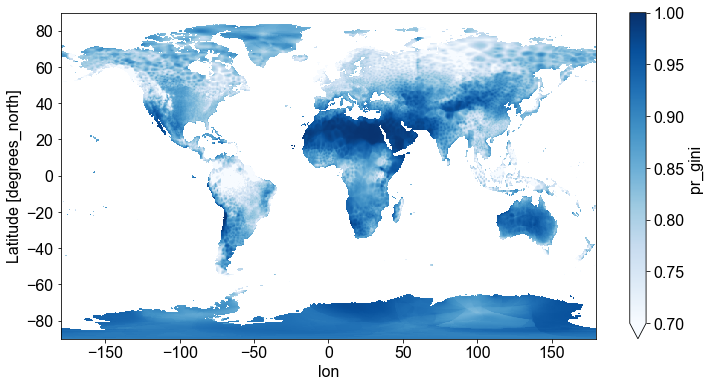

In [64]:
pr_gini.pr_gini.mean(dim='year').plot(vmin=0.7,vmax=1,cmap='Blues')

In [95]:
gini_trend_pr = pr_gini.pr_gini.polyfit(dim = "year", deg = 1)

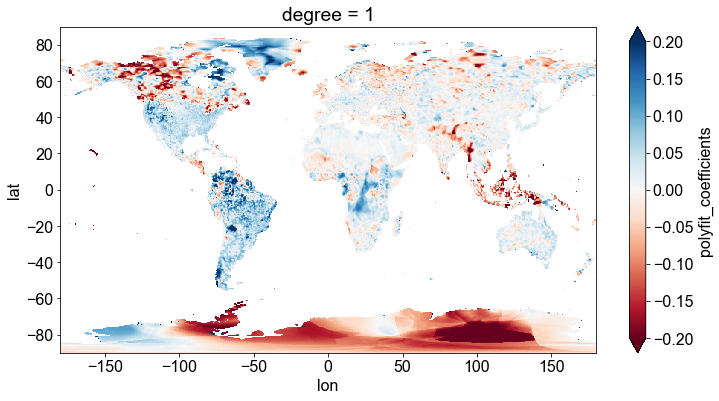

In [96]:
gini_change_pr = (gini_trend_pr.sel(degree=1).polyfit_coefficients*(endyear-startyear+1))
gini_change_pr.plot(vmin=-0.2,vmax=0.2,cmap='RdBu')#,title='daily P gini trend, 41y')



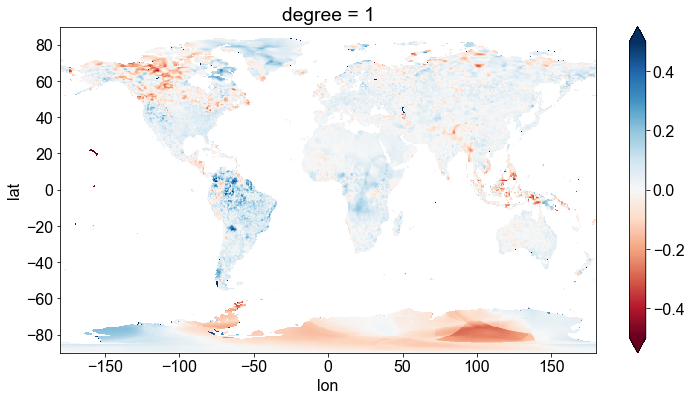

In [152]:
(gini_change/gini_ds.mean(dim='year')).plot(vmin=-0.5,vmax=0.5,cmap='RdBu')

### daily et gini

In [72]:
gleam_ds = xr.open_mfdataset(gleam_dir+'*.nc')

In [73]:
gleam_ds


<xarray.Dataset>
Dimensions:  (time: 15706, lon: 1440, lat: 720)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2022-12-31
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88
Data variables:
    E        (time, lat, lon) float32 dask.array<chunksize=(366, 720, 1440), meta=np.ndarray>
Attributes:
    Dataset:      Global Land Evaporation Amsterdam Model
    Version:      3.8a
    Authors:      Hydro-Climate Extremes Lab (H-CEL)
    Institution:  Ghent University
    Contact:      info@gleam.eu
    Reference1:   Martens, B. et al. 2017: GLEAM v3: satellite-based land eva...
    Reference2:   Miralles, D.G. et al. 2011: Global land-surface evaporation...

In [77]:
#compute annual gini
startyear = 1980
endyear = 2022
et_gini = np.nan*np.zeros((endyear-startyear+1,gleam_ds.lat.shape[0],gleam_ds.lon.shape[0]))

for i,yr in enumerate(range(startyear,endyear+1)):
    print(yr)
    #subset year cpc, sort, apply gini function
    tinds = gleam_ds.time[gleam_ds.time.dt.year == yr]
    gleam_yr = gleam_ds.sel(time=tinds).E
    gleam_sorted = np.sort(gleam_yr.values,axis=0)
    et_gini[i,:,:] = np.apply_along_axis(gini,0,gleam_sorted)


# to dataset
gini_ds = xr.DataArray(et_gini,coords={'year':np.arange(startyear,endyear+1),'lat':gleam_ds.lat,'lon':gleam_ds.lon})
gini_ds = gini_ds.to_dataset(dim=None,name='et_gini')
gini_ds.assign_attrs({'source':'https://www.gleam.eu/#downloads',
                   'origin':'Global Land Evaporation Amsterdam Model, GLEAM v3.8a',
                   'index':'annual daily evapotranspiration gini coefficient, 1980-2022'})

#save
gini_ds.to_netcdf('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/plcl/data/hydro-gini/annual_daily_et_gini__1980-2020.nc')


1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022


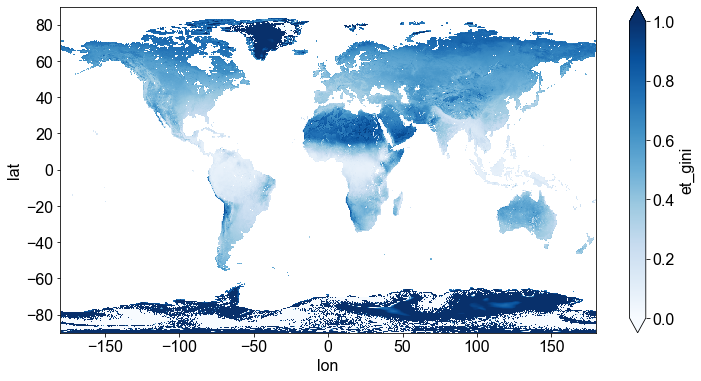

In [80]:
gini_ds.et_gini.mean(dim='year').plot(vmin=0,vmax=1,cmap='Blues')

In [87]:
gini_trend_et 

<xarray.DataArray 'polyfit_coefficients' (lat: 720, lon: 1440)>
array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan, -0.03199306, -0.03308521, ..., -0.02983639,
        -0.03045833, -0.03064947],
       [        nan, -0.02214999, -0.02218955, ..., -0.02207622,
        -0.02210476, -0.0221223 ],
       [        nan, -0.02014591, -0.02013357, ..., -0.02020129,
        -0.02017453, -0.02015897]])
Coordinates:
    degree   int64 1
  * lat      (lat) float64 89.88 89.62 89.38 89.12 ... -89.38 -89.62 -89.88
  * lon      (lon) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

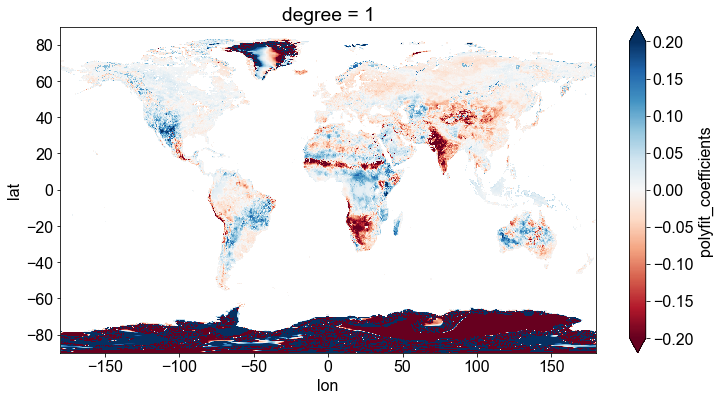

In [90]:
gini_change_et.plot(vmin=-0.2,vmax=0.2,cmap='RdBu')#,title='daily P gini trend, 41y')



## CMIP daily pr and et GINI

In [5]:
#water-year transformations
def wyAgg(ds,op):
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    #print('computing NH water year P, ET, Q.', flush=True)
    nh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 10, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = this_v_m_e_ds.time.dt.year.where(this_v_m_e_ds.time.dt.month < 7, this_v_m_e_ds.time.dt.year + 1)
    this_v_m_e_monthly['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = this_v_m_e_monthly.lat>=0.0
    northern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = this_v_m_e_monthly.lat<0.0
    southern_hemi = this_v_m_e_monthly.sel(lat=this_v_m_e_monthly.lat.values[southern_hemi_latmask])

    # aggregate each hemisphere to its respective water-year level:
    print('computing hemispheres.', flush=True)
    if op == 'sum':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').sum(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').sum(dim='time')
    elif op == 'mean':
        # northern
        this_v_m_e_nhwy_sum = northern_hemi.groupby('water_year_nh').mean(dim='time')
        # southern
        this_v_m_e_shwy_sum = southern_hemi.groupby('water_year_sh').mean(dim='time')
    else:
        print('not a valid operation')
        
    # merge north and southern hemispheres together into one water-year dataset:
    print('merging hemispheres.', flush=True)

    this_v_m_e_nhwy_sum = this_v_m_e_nhwy_sum.rename({'water_year_nh':'water_year'})
    this_v_m_e_shwy_sum = this_v_m_e_shwy_sum.rename({'water_year_sh':'water_year'})

    this_v_m_e_wateryear_sum = xr.merge([this_v_m_e_nhwy_sum, this_v_m_e_shwy_sum])
    this_v_m_e_wateryear_sum = this_v_m_e_wateryear_sum
    
    return this_v_m_e_wateryear_sum

def getHemiWY(ds):
    
    ds_wy = ds
    
    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 10, ds.time.dt.year + 1)
    ds_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = ds.time.dt.year.where(ds.time.dt.month < 7, ds.time.dt.year + 1)
    ds_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = ds_wy.lat>=0.0
    northern_hemi = ds_wy.sel(lat=ds_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = ds_wy.lat<0.0
    southern_hemi = ds_wy.sel(lat=ds_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

In [6]:
cmip_dir = '/dartfs-hpc/rc/lab/C/CMIG/Data/ClimateModels/CMIP6/historical/pr_day/'


In [7]:
### gather CMIP ET ensemble
# simple function to get unique elements in lists -- to sort thru files
def unique(lst):
 
    unique_list = []
    for x in lst:
        if x not in unique_list:
            unique_list.append(x)
    return unique_list

fnames = os.listdir(cmip_dir)

#define ensemble
models = unique([fn.split('_')[2] for fn in fnames])[:-4]

#populate variants per model
modvars = {}
for model in models:
    
    fnames = glob.glob(cmip_dir+'pr_day_'+model+'*.nc')
    modvars[model] = unique([fn.split('/')[-1].split('_')[4] for fn in fnames])
    

In [11]:
save_dir = '/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/CMIP6_pr_gini/'

In [22]:
models[20]

'MPI-ESM1-2-LR'

In [ ]:


#compute water year gini
startyear = 1980
endyear = 2015

for model in models[20:]:
    for variant in modvars[model]:
        print(model,variant)
        
        #load cmip pr daily:
        ds = xr.open_mfdataset(cmip_dir+'pr_day_'+model+'_historical_'+variant+'*.nc')

        # split northern and southern hemis, set water year coord
        nh,sh,nhmask,shmask = getHemiWY(ds)
        gini_hold = []

        for i,yr in enumerate(range(startyear,endyear+1)):
            #subset time
            nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
            shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])
            #sort
            nhyr_sorted = np.sort(nhyr.pr.values,axis=0)
            shyr_sorted = np.sort(shyr.pr.values,axis=0)
            #apply gini
            nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
            shgini = np.apply_along_axis(gini,0,shyr_sorted)
            #combine and store
            nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
            shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
            nhgds = nhgds.to_dataset(name='Pgini_wy')
            shgds = shgds.to_dataset(name='Pgini_wy')
            gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)

        # to dataset
        pr_gini_wy = xr.concat(gini_hold,dim='water_year')
        pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

        pr_gini_wy.assign_attrs({'model':model,
                           'variant':variant,
                           'index':'water-year daily rainfall gini coefficient, ' + str(startyear) + '-' + str(endyear)})
        #save
        pr_gini_wy.to_netcdf(save_dir+'pr_day_gini_' + model + '_' + variant +'_historical_' + str(startyear) + '-' + str(endyear) + '.nc')

MPI-ESM1-2-LR r1i1p1f1
MPI-ESM1-2-LR r9i1p1f1
MPI-ESM1-2-LR r2i1p1f1


In [ ]:
glob.glob(save_dir)

In [125]:
#list of water-year gini datasets
gini_hold = []

#compute water year gini
startyear = 2002
endyear = 2022

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(gpcp_ds)

for i,yr in enumerate(range(startyear,endyear+1)):
    if i%5==0: print(yr)
    #subset time
    nhyr = nh.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.values,axis=0)
    shyr_sorted = np.sort(shyr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)


In [127]:
# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

pr_gini_wy.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'GPCP DAILY V1.3',
                   'index':'water-year daily rainfall gini coefficient, 2002-2022'})

<xarray.Dataset>
Dimensions:        (time: 60265, bnds: 2, lat: 32, lon: 128)
Coordinates:
  * time           (time) datetime64[ns] 1850-01-01T12:00:00 ... 2014-12-31T1...
  * lat            (lat) float64 -87.86 -85.1 -82.31 ... -6.977 -4.186 -1.395
  * lon            (lon) float64 0.0 2.812 5.625 8.438 ... 351.6 354.4 357.2
Dimensions without coordinates: bnds
Data variables:
    time_bnds      (time, bnds) datetime64[ns] dask.array<chunksize=(365, 2), meta=np.ndarray>
    lat_bnds       (time, lat, bnds) float64 dask.array<chunksize=(365, 32, 2), meta=np.ndarray>
    lon_bnds       (time, lon, bnds) float64 dask.array<chunksize=(365, 128, 2), meta=np.ndarray>
    pr             (time, lat, lon) float32 dask.array<chunksize=(365, 32, 128), meta=np.ndarray>
    water_year_nh  (time) int64 1850 1850 1850 1850 1850 ... 2015 2015 2015 2015
    water_year_sh  (time) int64 1850 1850 1850 1850 1850 ... 2015 2015 2015 2015
Attributes: (12/44)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  84006.0
    creation_date:          2021-02-20T12:02:45Z
    ...                     ...
    title:                  MIROC-ES2L output prepared for CMIP6
    variable_id:            pr
    variant_label:          r24i1p1f2
    license:                CMIP6 model data produced by MIROC is licensed un...
    cmor_version:           3.3.2
    tracking_id:            hdl:21.14100/68b8e90f-2f06-4456-82ba-70b4a2dbede8

In [10]:
# load refgrid
cpc = xr.open_mfdataset(cpc_dir + '*.nc')

# load landmask, regrid
mask = xr.open_dataset('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/IMERG_land_sea_mask.nc')
mask = mask.interp_like(cpc)
mask = mask.landseamask < 75

In [107]:
runs = os.listdir(save_dir)
dslist = []
mvstrlist = []
for r in runs:
    mvstr = r.split('_')[3] + '_' + r.split('_')[4]
    print(mvstr)
    mvstrlist.append(mvstr)
    ds = xr.open_dataset(save_dir+r)
    dsinterp = ds.Pgini_wy.interp_like(cpc).where(mask)
    dsinterp = dsinterp.to_dataset(name='Pgini_wy').assign_coords({'model_variant':mvstr})
    dslist.append(dsinterp)

cmipGp_ds = xr.concat(dslist,'model_variant')

IPSL-CM6A-LR_r3i1p1f1
ACCESS-ESM1-5_r5i1p1f1
MIROC6_r25i1p1f1
CNRM-ESM2-1_r10i1p1f2
ACCESS-ESM1-5_r2i1p1f1
ACCESS-ESM1-5_r24i1p1f1
ACCESS-CM2_r1i1p1f1
EC-Earth3_r17i1p1f1
EC-Earth3_r7i1p1f1
CNRM-CM6-1-HR_r1i1p1f2
MIROC6_r29i1p1f1
MIROC6_r26i1p1f1
HadGEM3-GC31-LL_r3i1p1f3
INM-CM5-0_r9i1p1f1
CNRM-CM6-1_r25i1p1f2
CNRM-ESM2-1_r8i1p1f2
MIROC-ES2L_r8i1p1f2
ACCESS-ESM1-5_r19i1p1f1
MIROC-ES2L_r15i1p1f2
IPSL-CM5A2-INCA_r1i1p1f1
MPI-ESM-1-2-HAM_r2i1p1f1
CNRM-CM6-1_r13i1p1f2
ACCESS-ESM1-5_r18i1p1f1
CanESM5_r3i1p1f1
MIROC6_r7i1p1f1
CanESM5_r18i1p1f1
CNRM-CM6-1_r1i1p1f2
MIROC-ES2L_r25i1p1f2
CanESM5_r1i1p2f1
MIROC6_r5i1p1f1
HadGEM3-GC31-MM_r4i1p1f3
ACCESS-ESM1-5_r17i1p1f1
INM-CM5-0_r3i1p1f1
MIROC6_r30i1p1f1
CNRM-CM6-1_r7i1p1f2
CNRM-CM6-1_r19i1p1f2
UKESM1-0-LL_r10i1p1f2
MPI-ESM-1-2-HAM_r1i1p1f1
MIROC6_r24i1p1f1
MIROC-ES2L_r20i1p1f2
INM-CM5-0_r5i1p1f1
CNRM-CM6-1_r22i1p1f2
UKESM1-0-LL_r4i1p1f2
UKESM1-0-LL_r11i1p1f2
CNRM-CM6-1_r28i1p1f2
INM-CM5-0_r8i1p1f1
MIROC6_r12i1p1f1
CNRM-ESM2-1_r3i1p1f2
MPI-ESM1-2

In [110]:
cmipGp_ds.to_netcdf(save_dir+'pr_day_gini_historical_1980-2015_ensemble.nc')


In [ ]:
#compute and save trends
cmip_gp_trends = cmipGp_ds.polyfit('water_year',deg=1)
cmip_gp_trends.to_netcdf(save_dir+'CMIP6_Gp_trends_ensemble_1980-2015.nc')


def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift### prep mswep and gpcc data

In [23]:

def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

In [18]:
#regrid mswep
mswep = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/MSWEP_V280/Past/Daily/*.nc')
mswep = flipLon360(mswep)
#mswep_rs = mswep.interp_like(cpc)
#mswep_rs.to_netcdf(save_dir+'MSWEP_V280_p5.nc')

In [27]:
mswep_rs = mswep.interp_like(cpc_ds)


In [ ]:
mswep_rs.precipitation.sel(time=mswep_rs.time[50]).plot()

In [7]:
mswep = xr.open_mfdataset(save_dir+'MSWEP_V280_p5.nc')

In [8]:
mswep = mswep.sortby('lat')

In [9]:
def getHemiWY(cpc_ds):
    cpcdaily_wy = cpc_ds

    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 10, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 7, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = cpcdaily_wy.lat>=0.0
    northern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = cpcdaily_wy.lat<0.0
    southern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

In [14]:
# make northern hemisphere water year var:
mswep_wy = mswep.precipitation
nh_wateryears = mswep.time.dt.year.where(mswep.time.dt.month < 10, mswep.time.dt.year + 1)
mswep_wy['water_year_nh'] = nh_wateryears

# southern hemisphere water year = jul->jun

# make s.h. water year
#print('computing SH water year P, ET, Q.', flush=True)
sh_wateryears = mswep.time.dt.year.where(mswep.time.dt.month < 7, mswep.time.dt.year + 1)
mswep_wy['water_year_sh'] = sh_wateryears

# select data for northern hemisphere - I'm giving the equator to the North...
northern_hemi_latmask = mswep_wy.lat>=0.0
northern_hemi = mswep_wy.sel(lat=mswep_wy.lat.values[northern_hemi_latmask])

# ... and for southern hemisphere
southern_hemi_latmask = mswep_wy.lat<0.0
southern_hemi = mswep_wy.sel(lat=mswep_wy.lat.values[southern_hemi_latmask])


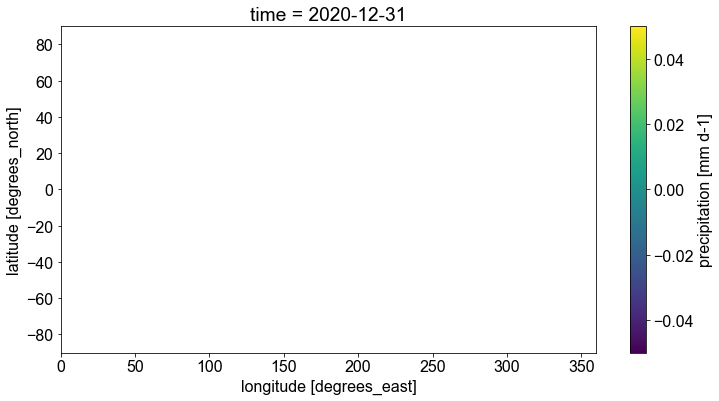

<xarray.Dataset>
Dimensions:        (time: 16436, lat: 360, lon: 720)
Coordinates:
  * lat            (lat) float64 -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon            (lon) float64 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time           (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2023-12-31
Data variables:
    precipitation  (time, lat, lon) float32 dask.array<chunksize=(16436, 360, 720), meta=np.ndarray>
    water_year_nh  (time) int64 1979 1979 1979 1979 1979 ... 2024 2024 2024 2024
    water_year_sh  (time) int64 1979 1979 1979 1979 1979 ... 2024 2024 2024 2024
Attributes:
    history:  Created on 2021-02-03 20:47

In [10]:
#list of water-year gini datasets
gini_hold = []

#compute water year gini
startyear = 1980
endyear = 1981

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(mswep)

for i,yr in enumerate(range(startyear,endyear+1)):
    if i%5==0: print(yr)
    #subset time
    nhyr = nh.precipitation.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.precipitation.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.values,axis=0)
    shyr_sorted = np.sort(shyr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)




1980


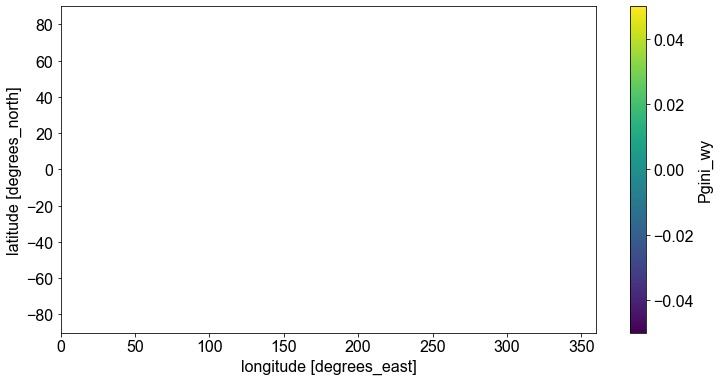

In [11]:
gini_hold[0].plot()


In [ ]:
# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(startyear,endyear+1)})

pr_gini_wy.assign_attrs({'source':'https://www.ncei.noaa.gov/data/global-precipitation-climatology-project-gpcp-daily/',
                   'origin':'MSWEP V280 daily 0.05 degree, regridded to 0.5 degree',
                   'index':'water-year daily rainfall gini coefficient, 1980-2022'})

#save
pr_gini_wy.to_netcdf('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/MSWEP_daily_pr_gini_water_year_1980-2022.nc')


### GPCC

In [13]:
def flipLon360(ds):
    shift = int(ds.lon.shape[0]/2)
    dsshift = ds.roll(lon=shift,roll_coords=True)
    lon_180 = ds.lon.values + 180
    dsshift = dsshift.assign_coords(lon=lon_180)
    return dsshift

#regrid and fliplon
gpcc = xr.open_mfdataset('/dartfs-hpc/rc/lab/C/CMIG/Data/Observations/GPCC/v2022_daily/*.nc')
gpcc_rs = flipLon360(gpcc)
gpcc_rs = gpcc_rs.interp_like(cpc_ds.sel(time=cpc_ds.time[0]))



In [15]:
def getHemiWY(cpc_ds):
    cpcdaily_wy = cpc_ds

    # northen hemisphere water-year  = oct->sep
    # make northern hemisphere water year var:
    nh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 10, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_nh'] = nh_wateryears

    # southern hemisphere water year = jul->jun

    # make s.h. water year
    #print('computing SH water year P, ET, Q.', flush=True)
    sh_wateryears = cpc_ds.time.dt.year.where(cpc_ds.time.dt.month < 7, cpc_ds.time.dt.year + 1)
    cpcdaily_wy['water_year_sh'] = sh_wateryears

    # select data for northern hemisphere - I'm giving the equator to the North...
    northern_hemi_latmask = cpcdaily_wy.lat>=0.0
    northern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[northern_hemi_latmask])

    # ... and for southern hemisphere
    southern_hemi_latmask = cpcdaily_wy.lat<0.0
    southern_hemi = cpcdaily_wy.sel(lat=cpcdaily_wy.lat.values[southern_hemi_latmask])

    return northern_hemi,southern_hemi,northern_hemi_latmask,southern_hemi_latmask

In [16]:
#list of water-year gini datasets
gini_hold = []

#compute water year gini
startyear = 1982
endyear = 2021

# split northern and southern hemis, set water year coord
nh,sh,nhmask,shmask = getHemiWY(gpcc_rs)

for i,yr in enumerate(range(startyear,endyear+1)):
    if i%5==0: print(yr)
    #subset time
    nhyr = nh.precip.sel(time=nh.time[nh.water_year_nh==yr])
    shyr = sh.precip.sel(time=sh.time[sh.water_year_sh==yr])
    #sort
    nhyr_sorted = np.sort(nhyr.values,axis=0)
    shyr_sorted = np.sort(shyr.values,axis=0)
    #apply gini
    nhgini = np.apply_along_axis(gini,0,nhyr_sorted)
    shgini = np.apply_along_axis(gini,0,shyr_sorted)
    #combine and store
    nhgds = xr.DataArray(nhgini,coords={'lat':nhyr.lat,'lon':nhyr.lon})
    shgds = xr.DataArray(shgini,coords={'lat':shyr.lat,'lon':shyr.lon})
    nhgds = nhgds.to_dataset(name='Pgini_wy')
    shgds = shgds.to_dataset(name='Pgini_wy')
    gini_hold.append(xr.merge([nhgds,shgds]).Pgini_wy)




1982


KeyboardInterrupt: 

In [52]:
# to dataset
pr_gini_wy = xr.concat(gini_hold,dim='water_year')
pr_gini_wy = pr_gini_wy.assign_coords({'water_year':np.arange(1982,2022)})

pr_gini_wy.assign_attrs({'source':'https://opendata.dwd.de/climate_environment/GPCC/html/fulldata-daily_v2022_doi_download.html',
                   'origin':'GPCC v2022 daily 1 degree, regridded to 0.5 degree',
                   'index':'water-year daily rainfall gini coefficient, 1982-2021'})

#save
pr_gini_wy.to_netcdf('/dartfs-hpc/rc/lab/C/CMIG/clesk/projects/pexq/data/GPCC_daily_pr_gini_water_year_1982-2021.nc')


In [1]:
cpc

NameError: name 'cpc' is not defined